In [1]:
import pandas as pd
import numpy as np

In [2]:
heart_disease = pd.read_csv("../Dataset/heart-disease.csv")
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
len(heart_disease)

303

consulting the map and it says linearSVC
https://scikit-learn.org/stable/machine_learning_map.html}

In [4]:
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split


#setup random seed
np.random.seed(42)

x = heart_disease.drop("target",axis = 1)
y = heart_disease["target"]



In [5]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

#instantiate linarSVC
clf = LinearSVC()
clf.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [6]:
clf.score(x_test,y_test)

0.8688524590163934

In [7]:
y_preds = clf.predict(x_test)
y_preds

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [8]:
y_preds_df = pd.DataFrame(y_preds, columns=["Predicted_label"])
y_preds_df.head()

,Predicted_label
0,0
1,1
2,1
3,0
4,1


In [9]:
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

x = heart_disease.drop("target",axis = 1)
y = heart_disease["target"]

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)


clf = RandomForestClassifier()
clf.fit(x_train,y_train)

clf.score(x_test,y_test)



0.8524590163934426

In [10]:
# fitting the model and using it to make the prediction on our data

## fitting the model to the data
# x = features, features variable, data
# y = labels,targets,target variable

In [11]:
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

x = heart_disease.drop("target",axis = 1)
y = heart_disease["target"]

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)


clf = RandomForestClassifier()

#fit the model to the data(training machine learning model)
clf.fit(x_train,y_train)
#using the pattern which machine learning learned above
clf.score(x_test,y_test)


0.8524590163934426

In [12]:
x.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [13]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

In [14]:
#using a tained model to make predictions
# 2 ways to do that - predict() vs predict_proba()

In [15]:
clf.predict(x_test)

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [16]:
np.array([y_test])

array([[0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
        0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0]])

In [17]:
#compare predictions to truth labels to evaluate model
np.mean(y_preds == y_test) #what we did here was to predict the score as given by our model just checked the trained model outcomes with the actual model outcomes

np.float64(0.8688524590163934)

In [18]:
clf.score(x_test,y_test)

0.8524590163934426

In [19]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_preds)

0.8688524590163934

In [20]:
#make predictions with predict_probe()
#predict proba returns the probablities of the classification labels - prob of label being true

clf.predict_proba(x_test[:5])

array([[0.89, 0.11],
       [0.49, 0.51],
       [0.43, 0.57],
       [0.84, 0.16],
       [0.18, 0.82]])

In [21]:
#lets predict() on the same data
clf.predict(x_test[:5])


array([0, 1, 1, 0, 1])

In [22]:
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

#create x and y

x = heart_disease.drop("target",axis=1)
y = heart_disease["target"]

#create traain/test

x_test,x_train,y_test,y_train = train_test_split(x,y, test_size=0.2)

#create classifier model instance

clf = RandomForestClassifier(n_estimators=500
                             )

#fit classifier to trainning data

clf.fit(x_train,y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [23]:
clf.score(x_train,y_train)

1.0

In [24]:
clf.score(x_test,y_test)

0.7892561983471075

In [25]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

model = RandomForestRegressor(n_estimators=50)

model.fit(x_train,y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numbe

In [26]:
model.score(x_test,y_test)

0.5483896551724138

In [27]:
model.score(x_train,y_train)

0.9178098089259847

In [28]:
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

#create x and y

x = heart_disease.drop("target",axis=1)
y = heart_disease["target"]

#create traain/test

x_test,x_train,y_test,y_train = train_test_split(x,y, test_size=0.2)

#create classifier model instance

clf = RandomForestClassifier(n_estimators=500)

#fit classifier to trainning data

clf.fit(x_train,y_train);


In [29]:
clf.score(x_test,y_test)

0.7892561983471075

In [30]:
arr = cross_val_score(clf,x,y)
print(arr.mean())

0.8313661202185791


### classification model evaluation metric

1. accuracy
2. area under ROC curve
3. Confusion  metrix
4. Classification report

accuracy

In [31]:
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

x = heart_disease.drop("target",axis=1)
y = heart_disease["target"]

clf = RandomForestClassifier()
cross_val_score = cross_val_score(clf,x,y)

In [32]:
np.mean(cross_val_score)

np.float64(0.8248087431693989)

In [33]:
print(f"Heart disease classifier acc: {np.mean(cross_val_score)*100}")

Heart disease classifier acc: 82.48087431693989


**Area under reciver operating characteristic curve(AUC)**

* Area under curve(AUC)
* ROC curve

comparison of models true +ve and false +ve

* true +ve : model predicts  1 and  real label is 1
* False +ve: model predicts 1 and when truth is 0
* True -ve : models  predicts 0 and truth is 0
* False -ve: models predicts 1 but result is 0

In [37]:
from sklearn.metrics import roc_curve

#fitting classifier
clf.fit(x_train,y_train)

#make pred with prob
y_preds = clf.predict_proba(x_test)
y_preds

array([[0.13, 0.87],
       [0.89, 0.11],
       [0.29, 0.71],
       [0.17, 0.83],
       [0.61, 0.39],
       [0.36, 0.64],
       [0.3 , 0.7 ],
       [0.37, 0.63],
       [0.17, 0.83],
       [0.06, 0.94],
       [0.19, 0.81],
       [0.42, 0.58],
       [0.07, 0.93],
       [0.84, 0.16],
       [0.05, 0.95],
       [0.18, 0.82],
       [0.37, 0.63],
       [0.51, 0.49],
       [0.51, 0.49],
       [0.12, 0.88],
       [0.85, 0.15],
       [0.45, 0.55],
       [0.3 , 0.7 ],
       [0.34, 0.66],
       [0.44, 0.56],
       [0.94, 0.06],
       [0.31, 0.69],
       [0.44, 0.56],
       [0.28, 0.72],
       [0.35, 0.65],
       [0.03, 0.97],
       [0.04, 0.96],
       [0.13, 0.87],
       [0.33, 0.67],
       [0.12, 0.88],
       [0.4 , 0.6 ],
       [0.73, 0.27],
       [0.  , 1.  ],
       [0.57, 0.43],
       [0.22, 0.78],
       [0.08, 0.92],
       [0.29, 0.71],
       [0.74, 0.26],
       [0.46, 0.54],
       [0.04, 0.96],
       [0.12, 0.88],
       [0.11, 0.89],
       [0.45,

In [39]:
y_probs_positive = y_preds[:,1]
y_probs_positive

array([0.87, 0.11, 0.71, 0.83, 0.39, 0.64, 0.7 , 0.63, 0.83, 0.94, 0.81,
       0.58, 0.93, 0.16, 0.95, 0.82, 0.63, 0.49, 0.49, 0.88, 0.15, 0.55,
       0.7 , 0.66, 0.56, 0.06, 0.69, 0.56, 0.72, 0.65, 0.97, 0.96, 0.87,
       0.67, 0.88, 0.6 , 0.27, 1.  , 0.43, 0.78, 0.92, 0.71, 0.26, 0.54,
       0.96, 0.88, 0.89, 0.55, 0.16, 0.92, 0.97, 0.09, 0.75, 0.61, 0.55,
       0.71, 1.  , 0.61, 0.19, 0.18, 0.11, 0.13, 0.56, 0.19, 0.19, 0.81,
       0.16, 0.49, 0.73, 0.65, 0.75, 0.41, 0.69, 0.84, 0.62, 0.62, 0.78,
       0.28, 0.18, 0.13, 0.08, 0.74, 0.93, 0.96, 0.86, 0.14, 0.21, 0.21,
       0.11, 0.81, 0.97, 0.83, 0.57, 0.45, 0.86, 0.96, 0.39, 0.94, 0.81,
       0.24, 0.72, 0.44, 0.59, 0.13, 0.78, 0.95, 0.88, 0.73, 0.95, 0.17,
       0.94, 0.25, 0.64, 0.31, 0.16, 0.22, 0.97, 0.36, 0.64, 0.88, 0.86,
       0.66, 0.69, 0.61, 0.74, 0.55, 0.4 , 0.84, 0.82, 0.76, 0.74, 0.86,
       0.86, 0.76, 0.35, 0.52, 0.23, 0.43, 0.83, 0.63, 0.83, 0.72, 0.75,
       0.14, 0.73, 0.87, 1.  , 0.55, 0.94, 0.2 , 0.

In [ ]:
#calc fpr, tpr, threshhold
fpr, tpr, thresholds = roc_curve(y_test,y_probs_positive)

# check false +ve rate
fpr

array([0.        , 0.        , 0.00917431, 0.00917431, 0.00917431,
       0.00917431, 0.00917431, 0.00917431, 0.02752294, 0.02752294,
       0.02752294, 0.04587156, 0.0733945 , 0.08256881, 0.08256881,
       0.09174312, 0.09174312, 0.11009174, 0.11926606, 0.12844037,
       0.1559633 , 0.1559633 , 0.16513761, 0.16513761, 0.17431193,
       0.18348624, 0.20183486, 0.23853211, 0.25688073, 0.26605505,
       0.27522936, 0.29357798, 0.29357798, 0.31192661, 0.33027523,
       0.34862385, 0.35779817, 0.37614679, 0.39449541, 0.40366972,
       0.44036697, 0.46788991, 0.48623853, 0.50458716, 0.50458716,
       0.51376147, 0.51376147, 0.53211009, 0.5412844 , 0.55963303,
       0.56880734, 0.56880734, 0.58715596, 0.60550459, 0.64220183,
       0.66972477, 0.68807339, 0.72477064, 0.76146789, 0.80733945,
       0.82568807, 0.85321101, 0.88990826, 0.89908257, 0.94495413,
       0.96330275, 1.        ])

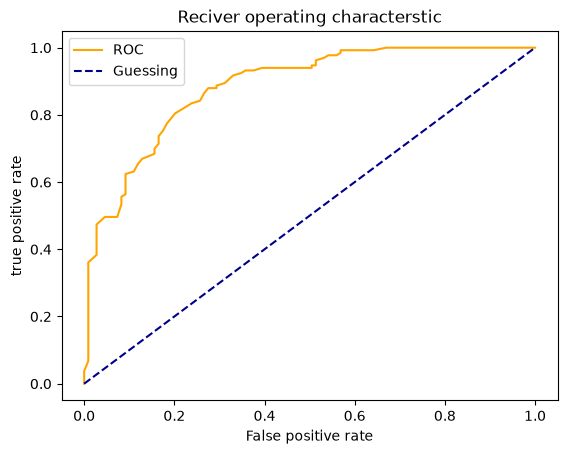

In [43]:
#creating func for plotting roc curve

import matplotlib.pyplot as plt

def plot_roc_curve(fpr,tpr):
    """
    Plot roc curve given the false positive rate fpr and true positive rate for tpr
    """
    plt.plot(fpr, tpr, color="orange",label="ROC")
    #plot lines with no predective power - baseline
    plt.plot([0,1],[0,1],color="darkblue",linestyle="--",label="Guessing")

    #customize the plot
    plt.xlabel("False positive rate")
    plt.ylabel("true positive rate")
    plt.title("Reciver operating characterstic")
    plt.legend()
    plt.show()

plot_roc_curve(fpr,tpr)

In [44]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_probs_positive)

0.8830447678830103

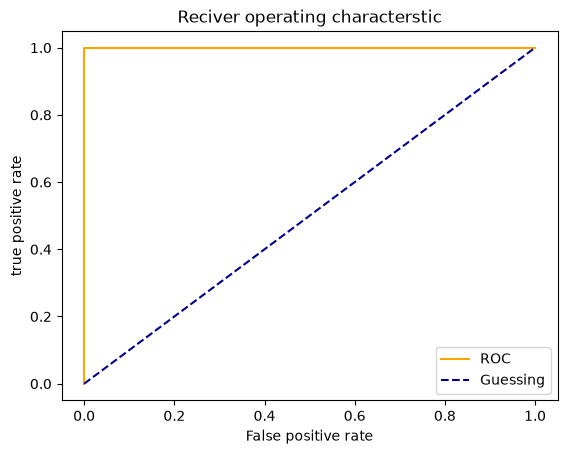

1.0

In [50]:
#what a perfect roc cureve looks like
fpr , tpr , thresholds = roc_curve(y_test,y_test)
plot_roc_curve(fpr,tpr)
#perfect auc score
roc_auc_score(y_test,y_test)

**Confusion Matrix**
* compares the label a model predicts and the actual labels it was suppose to predict, in essence giving you an idea where the model is getting confused

In [51]:
from sklearn.metrics import confusion_matrix

y_preds = clf.predict(x_test)

confusion_matrix(y_test,y_preds)

array([[ 69,  40],
       [  9, 124]])

In [52]:
#visualizae the confusion matrix
pd.crosstab(y_test,y_preds,rownames=["Actual labels"],colnames=["Pred labels"])

Pred labels,0,1
Actual labels,,
0,69,40
1,9,124


In [53]:
69+9+40+124

242

In [54]:
len(y_preds)

242

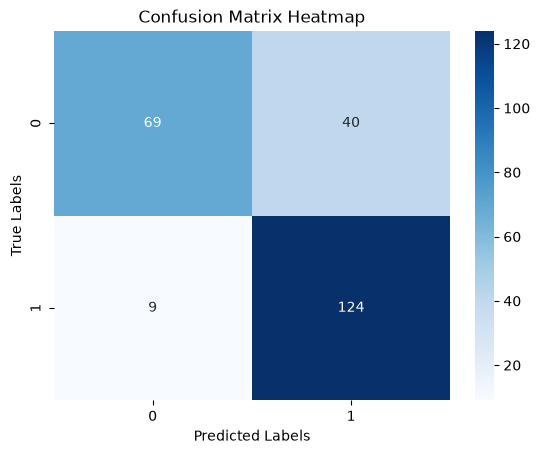

In [59]:
#make our confusion matrix visual with seaborn heapmap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

# 3. Add labels and show the plot
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix Heatmap")
plt.show()

